# Model Training Notebook

This notebook loads the training data, extracts the images and their matching labels, uses the extracted data to train a model, saves the model, and plots the metrics/loss over the epochs.

## Load Libraries and Configuration

This cell imports the necessary libraries and loads the configuration from `config.json`.

In [ ]:
import os
import csv
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

from config_loader import Config
from data_processing.data_encoder import DataEncoder
from cnn.CustomMetric import CustomMetric
from cnn.custom_loss import custom_loss
from cnn.model_mobilenetv2 import build_model

import tensorflow as tf
from keras import callbacks

from matplotlib import pyplot as plt
%matplotlib inline

nb_conf = Config('config.json')

## Check GPU Availability

This cell checks the number of available GPUs and lists them.

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Available GPU\'s:")
tf.config.list_physical_devices('GPU')

Num GPUs Available:  1
Available GPU's:


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Load and Encode Data

This cell initializes the data encoder, loads the training data and labels, and encodes them into arrays `X` and `y`. It also prints the reference points and center.

In [3]:
# import data encoder
encoder = DataEncoder(nb_conf)
data_dir = nb_conf.generator.train_data.data_dir
label_dir = Path(nb_conf.generator.train_data.labels_dir) / nb_conf.generator.train_data.label_file
X, y, ref_coords, ref_center = encoder(data_dir, label_dir)

print("Reference points: ", ref_coords, ref_coords.shape)
print("Reference center: ", ref_center, ref_center.shape)

Input encoded...
Input values normalized...
Shape:  (2000, 256, 256, 3)  Type:  <class 'numpy.ndarray'>  dtype:  float64
Labels generated from:  datasets/training/training.csv
Labels normalized...
Shape:  (2000, 8)  Type:  <class 'numpy.ndarray'>  dtype:  float64
Reference points:  [0.27734375 0.27734375 0.72265625 0.27734375 0.27734375 0.71875
 0.72265625 0.71875   ] (8,)
Reference center:  [0.5 0.5] (2,)


## Build Model

This cell builds the model using the input and output shapes derived from the data.

In [4]:
input_shape = X.shape[1:]
output_shape = y.shape[1]

metric = CustomMetric(ref_center, ref_coords, nb_conf)
model = build_model(input_shape, output_shape)

2024-11-24 02:12:55.147872: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2024-11-24 02:12:55.147933: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-11-24 02:12:55.147938: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-11-24 02:12:55.147974: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-24 02:12:55.147987: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/keremaras/Projects/aoi-pcb-v1/cnn/model_mobilenetv2.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for inpu

## Model Summary

This cell prints the summary of the model architecture.

In [ ]:
#model = get_model()
model.summary()

## Compile Model

This cell compiles the model with the Adam optimizer, custom loss function, and custom metric.

In [6]:
#custom metrics not yet implemented
model.compile(optimizer='Adam',
              loss=custom_loss,
              metrics=[metric.custom_metric])

## Set Up Callbacks

This cell sets up the early stopping, learning rate reduction, and CSV logger callbacks using the configuration parameters.

In [7]:
# os.chdir(os.path.join(models_dir, "Model_Logs"))
es_args = nb_conf.get_init_kwargs("training.early_stopping")
lr_args = nb_conf.get_init_kwargs("training.lr_schedule")
log_csv = nb_conf.get_init_kwargs("training.log_csv")

csv_logger = callbacks.CSVLogger(filename='cl_cm_test_logs.csv',
                       separator=',',
                       append=True)

early_stopping = callbacks.EarlyStopping(**es_args)

reduce_lr = callbacks.ReduceLROnPlateau(**lr_args)

# save_checkpoint = callbacks.ModelCheckpoint()

callbacks = [early_stopping,
             reduce_lr]

## Train Model

This cell trains the model using the training data, with validation split and specified number of epochs. It also uses the defined callbacks.

In [8]:
history = model.fit(X, y, validation_split=nb_conf.training.val_split, epochs=nb_conf.training.n_epochs, callbacks=callbacks)

Epoch 1/1000


2024-11-24 02:13:20.908455: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - custom_metric: 3.3194 - loss: 0.9991 - val_custom_metric: 3.1089 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 2/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - custom_metric: 2.5821 - loss: 0.0625 - val_custom_metric: 1.1279 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 3/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - custom_metric: 0.4784 - loss: 0.0186 - val_custom_metric: 0.0815 - val_loss: 9.5371e-04 - learning_rate: 0.0010
Epoch 4/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - custom_metric: 0.0343 - loss: 0.0040 - val_custom_metric: 0.0826 - val_loss: 7.8639e-04 - learning_rate: 0.0010
Epoch 5/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - custom_metric: 0.0353 - loss: 0.0039 - val_custom_metric: 0.0972 - val_loss: 8.0922e-04 - learning_rate: 0.0010
Epoch 6/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - custom_metric: 0.0314 - loss: 0.0038 - val_custom_metric: 0.1020 - val_loss: 8.2557e-04 - learning_rate: 0.0010
Epoch 7/1000

In [ ]:
# os.chdir(models_dir)
model.save("cl_cm_test_model")

## Plot Training Loss and Metrics

These cells plots the custom metric as well as the loss over the epochs for both training and validation data.

In [9]:
#list all data in history
print(history.history.keys())

dict_keys(['custom_metric', 'loss', 'val_custom_metric', 'val_loss', 'learning_rate'])


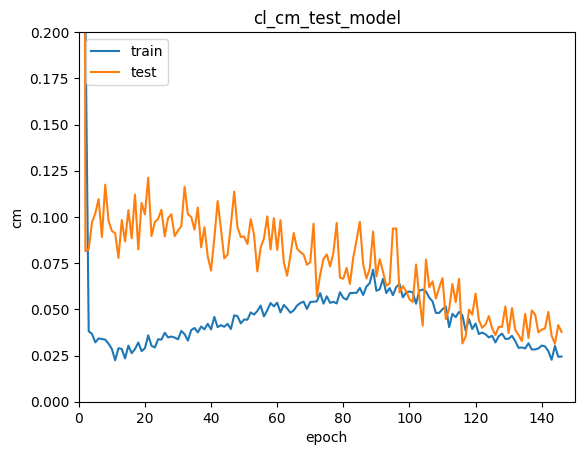

In [14]:
# summarize history for accuracy
plt.plot(history.history['custom_metric'])
plt.plot(history.history['val_custom_metric'])
plt.title('cl_cm_test_model')
plt.ylabel('cm')
plt.xlabel('epoch')
plt.xlim(0, 150)
plt.ylim(0, 0.2)
plt.legend(['train', 'test'], loc='upper left')
plt.show()

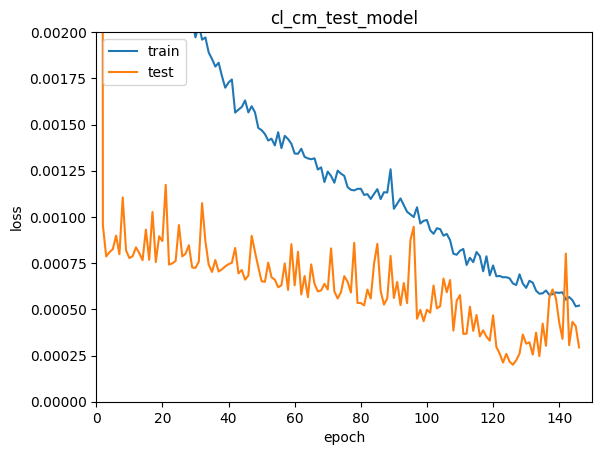

In [18]:
# Plot Training Metrics
plt.figure(figsize=(10, 6))
plt.plot(history.history['custom_metric'], label='Train Custom Metric', color='blue', linestyle='--', marker='o')
plt.plot(history.history['val_custom_metric'], label='Validation Custom Metric', color='red', linestyle='-', marker='x')
plt.title('Custom Metric Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Custom Metric', fontsize=14)
plt.xlim(0, len(history.history['custom_metric']) - 1)
plt.ylim(0, 0.2)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

# Plot Training Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss', color='blue', linestyle='--', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='-', marker='x')
plt.title('Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xlim(0, len(history.history['loss']) - 1)
plt.ylim(0, 0.002)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()